# Why We Need One-Hot Encoding: The Problem with Using Categorical Indices as Numerical Features

## The Question:
> "Why can't we just use the education index (0, 1, 2, 3) directly as a feature in our model? It's a regressor, not the dependent variable, so we won't have values like 1.5."

## The Answer:
The problem isn't about getting fractional predictions. **The problem is that the model will interpret the numerical index as having mathematical meaning** - treating the difference between categories as having equal intervals and ordering that doesn't reflect reality.

Let's demonstrate this with synthetic data!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Set random seed for reproducibility
np.random.seed(42)
sns.set_style('whitegrid')

## Part 1: Creating Synthetic Data

Let's create a dataset where education level affects income, but **NOT in a linear, ordered way**.

Education levels (ordered by frequency, as StringIndexer would do):
- **MSc** (most common) → Index 0 → Average Income: $75,000
- **Basic** (second most common) → Index 1 → Average Income: $35,000
- **BSc** (third most common) → Index 2 → Average Income: $55,000
- **PhD** (least common) → Index 3 → Average Income: $90,000

Notice: The index order (0, 1, 2, 3) does NOT match the real-world education progression or income progression!

In [2]:
# Define education levels with their true effects on income
education_data = {
    'MSc': {'count': 400, 'base_income': 75000, 'index': 0},
    'Basic': {'count': 300, 'base_income': 35000, 'index': 1},
    'BSc': {'count': 200, 'base_income': 55000, 'index': 2},
    'PhD': {'count': 100, 'base_income': 90000, 'index': 3}
}

# Create synthetic dataset
data_list = []

for edu_level, info in education_data.items():
    n = info['count']
    base_income = info['base_income']
    index = info['index']
    
    # Generate incomes with some random variation around the base
    incomes = np.random.normal(base_income, 8000, n)
    
    for income in incomes:
        data_list.append({
            'Education': edu_level,
            'EducationIndex': index,
            'Income': income
        })

df = pd.DataFrame(data_list)

print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head(10))
print("\nEducation level distribution:")
print(df['Education'].value_counts())

Dataset shape: (1000, 3)

First few rows:
  Education  EducationIndex        Income
0       MSc               0  78973.713224
1       MSc               0  73893.885591
2       MSc               0  80181.508305
3       MSc               0  87184.238851
4       MSc               0  73126.773002
5       MSc               0  73126.904344
6       MSc               0  87633.702524
7       MSc               0  81139.477833
8       MSc               0  71244.204913
9       MSc               0  79340.480349

Education level distribution:
Education
MSc      400
Basic    300
BSc      200
PhD      100
Name: count, dtype: int64


In [3]:
# Show the mapping between education, index, and average income
summary = df.groupby(['Education', 'EducationIndex'])['Income'].mean().reset_index()
summary = summary.sort_values('EducationIndex')
summary['Income'] = summary['Income'].round(0)

print("\n" + "="*60)
print("CRITICAL OBSERVATION: Index Order vs Reality")
print("="*60)
print(summary.to_string(index=False))
print("\nNotice: The index order (0→1→2→3) does NOT reflect:")
print("  - Educational progression: Basic < BSc < MSc < PhD")
print("  - Income progression: Basic < BSc < MSc < PhD")


CRITICAL OBSERVATION: Index Order vs Reality
Education  EducationIndex  Income
      MSc               0 75180.0
    Basic               1 34607.0
      BSc               2 55890.0
      PhD               3 90223.0

Notice: The index order (0→1→2→3) does NOT reflect:
  - Educational progression: Basic < BSc < MSc < PhD
  - Income progression: Basic < BSc < MSc < PhD


## Part 2: The WRONG Approach - Using Index as a Numerical Feature

Let's see what happens when we treat the education index as a numerical feature in a linear regression.

In [4]:
# Fit linear regression using EducationIndex as numerical feature
X_index = df[['EducationIndex']].values
y = df['Income'].values

model_wrong = LinearRegression()
model_wrong.fit(X_index, y)

# Get predictions
df['Predicted_Income_Wrong'] = model_wrong.predict(X_index)

print("\n" + "="*60)
print("WRONG APPROACH: Using EducationIndex as Numerical Feature")
print("="*60)
print(f"\nModel equation: Income = {model_wrong.intercept_:.2f} + {model_wrong.coef_[0]:.2f} × EducationIndex")
print(f"\nR² Score: {model_wrong.score(X_index, y):.4f}")

# Show predictions for each education level
print("\nPredictions by Education Level:")
comparison_wrong = df.groupby(['Education', 'EducationIndex']).agg({
    'Income': 'mean',
    'Predicted_Income_Wrong': 'mean'
}).round(0).reset_index()
comparison_wrong = comparison_wrong.sort_values('EducationIndex')
comparison_wrong['Error'] = (comparison_wrong['Predicted_Income_Wrong'] - comparison_wrong['Income']).round(0)
print(comparison_wrong.to_string(index=False))


WRONG APPROACH: Using EducationIndex as Numerical Feature

Model equation: Income = 61504.26 + -849.60 × EducationIndex

R² Score: 0.0016

Predictions by Education Level:
Education  EducationIndex  Income  Predicted_Income_Wrong    Error
      MSc               0 75180.0                 61504.0 -13676.0
    Basic               1 34607.0                 60655.0  26048.0
      BSc               2 55890.0                 59805.0   3915.0
      PhD               3 90223.0                 58955.0 -31268.0


### 🔴 The Problem!

The model assumes:
- Going from index 0→1 has the same effect as going from 1→2 or 2→3
- The relationship is linear: each increase in index adds/subtracts the same amount to income

But look at the actual data:
- Index 0 (MSc): $75,000
- Index 1 (Basic): $35,000 ← **HUGE drop!**
- Index 2 (BSc): $55,000 ← Goes back up!
- Index 3 (PhD): $90,000 ← Goes up even more!

The model tries to fit a **straight line** through data that doesn't follow a straight line pattern!

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


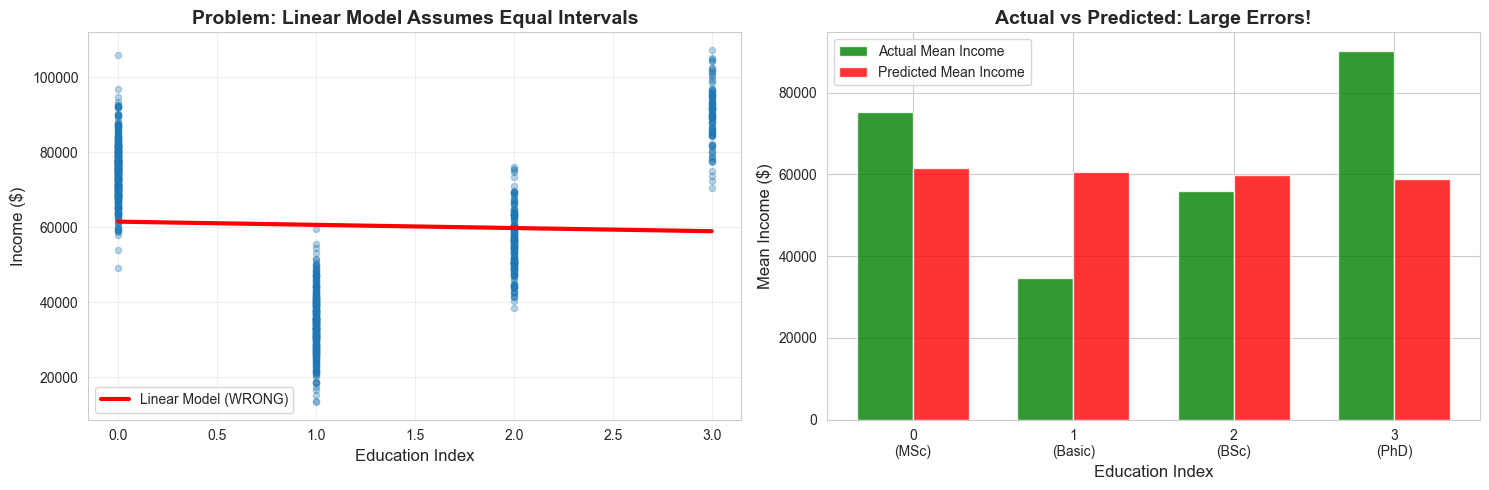


⚠️ Notice how the red bars (predictions) don't match the green bars (actual values)!


In [5]:
# Visualize the problem
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Scatter with linear regression line
axes[0].scatter(df['EducationIndex'], df['Income'], alpha=0.3, s=20)
axes[0].plot(df['EducationIndex'].unique(), 
             model_wrong.predict(df[['EducationIndex']].drop_duplicates().sort_values('EducationIndex')), 
             'r-', linewidth=3, label='Linear Model (WRONG)')
axes[0].set_xlabel('Education Index', fontsize=12)
axes[0].set_ylabel('Income ($)', fontsize=12)
axes[0].set_title('Problem: Linear Model Assumes Equal Intervals', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Actual means vs predicted
actual_means = df.groupby('EducationIndex')['Income'].mean()
predicted_means = df.groupby('EducationIndex')['Predicted_Income_Wrong'].mean()

x_pos = actual_means.index
width = 0.35

axes[1].bar(x_pos - width/2, actual_means, width, label='Actual Mean Income', alpha=0.8, color='green')
axes[1].bar(x_pos + width/2, predicted_means, width, label='Predicted Mean Income', alpha=0.8, color='red')
axes[1].set_xlabel('Education Index', fontsize=12)
axes[1].set_ylabel('Mean Income ($)', fontsize=12)
axes[1].set_title('Actual vs Predicted: Large Errors!', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['0\n(MSc)', '1\n(Basic)', '2\n(BSc)', '3\n(PhD)'])

plt.tight_layout()
plt.show()

print("\n⚠️ Notice how the red bars (predictions) don't match the green bars (actual values)!")

## Part 3: The Mathematical Problem

Let's make this even more explicit. When we use the index as a numerical feature, the model learns:

$$\text{Income} = \beta_0 + \beta_1 \times \text{EducationIndex}$$

This means:
- The model thinks that **the difference between any two consecutive education levels is the same**
- Going from MSc (0) to Basic (1) is treated the same as going from BSc (2) to PhD (3)
- The model cannot capture the non-linear, unordered relationship between education categories and income

In [6]:
# Calculate what the model is actually learning
coef = model_wrong.coef_[0]
intercept = model_wrong.intercept_

print("\n" + "="*60)
print("WHAT THE MODEL IS LEARNING (INCORRECTLY)")
print("="*60)
print(f"\nIntercept (β₀): ${intercept:,.2f}")
print(f"Coefficient (β₁): ${coef:,.2f} per index unit")
print(f"\nThis means:")
print(f"  - Base income (index=0): ${intercept:,.2f}")
print(f"  - Each increase in index {'increases' if coef > 0 else 'decreases'} income by ${abs(coef):,.2f}")

print(f"\nModel's predictions:")
for idx in range(4):
    pred = intercept + coef * idx
    edu_name = df[df['EducationIndex'] == idx]['Education'].iloc[0]
    actual = df[df['EducationIndex'] == idx]['Income'].mean()
    error = pred - actual
    print(f"  Index {idx} ({edu_name:5s}): Predicted=${pred:>8,.0f}  |  Actual=${actual:>8,.0f}  |  Error=${error:>8,.0f}")


WHAT THE MODEL IS LEARNING (INCORRECTLY)

Intercept (β₀): $61,504.26
Coefficient (β₁): $-849.60 per index unit

This means:
  - Base income (index=0): $61,504.26
  - Each increase in index decreases income by $849.60

Model's predictions:
  Index 0 (MSc  ): Predicted=$  61,504  |  Actual=$  75,180  |  Error=$ -13,676
  Index 1 (Basic): Predicted=$  60,655  |  Actual=$  34,607  |  Error=$  26,047
  Index 2 (BSc  ): Predicted=$  59,805  |  Actual=$  55,890  |  Error=$   3,915
  Index 3 (PhD  ): Predicted=$  58,955  |  Actual=$  90,223  |  Error=$ -31,267


## Part 4: The RIGHT Approach - One-Hot Encoding

Now let's use **one-hot encoding** (dummy variables) to treat each education level independently.

In [8]:
# Create one-hot encoded features (drop first to avoid dummy variable trap)
df_encoded = pd.get_dummies(df, columns=['Education'], prefix='Edu', drop_first=True)

print("\n" + "="*60)
print("ONE-HOT ENCODING: Creating Dummy Variables")
print("="*60)
print("\nOriginal columns:")
print(df[['Education', 'EducationIndex', 'Income']].head())
print("\nAfter one-hot encoding:")
# Show what columns were actually created
edu_cols = [col for col in df_encoded.columns if col.startswith('Edu_')]
print(f"Created dummy columns: {edu_cols}")
print("\nFirst few rows of encoded data:")
print(df_encoded[edu_cols + ['Income']].head())
print("\nNote: Each education level is now a separate binary (0/1) feature!")
print(f"Note: One category was dropped (reference category) to avoid multicollinearity.")


ONE-HOT ENCODING: Creating Dummy Variables

Original columns:
  Education  EducationIndex        Income
0       MSc               0  78973.713224
1       MSc               0  73893.885591
2       MSc               0  80181.508305
3       MSc               0  87184.238851
4       MSc               0  73126.773002

After one-hot encoding:
Created dummy columns: ['Edu_Basic', 'Edu_MSc', 'Edu_PhD']

First few rows of encoded data:
   Edu_Basic  Edu_MSc  Edu_PhD        Income
0      False     True    False  78973.713224
1      False     True    False  73893.885591
2      False     True    False  80181.508305
3      False     True    False  87184.238851
4      False     True    False  73126.773002

Note: Each education level is now a separate binary (0/1) feature!
Note: One category was dropped (reference category) to avoid multicollinearity.


In [9]:
# Fit linear regression using one-hot encoded features
# Get the actual column names created by get_dummies
feature_cols = [col for col in df_encoded.columns if col.startswith('Edu_')]
X_onehot = df_encoded[feature_cols].values
y = df_encoded['Income'].values

model_correct = LinearRegression()
model_correct.fit(X_onehot, y)

# Get predictions
df_encoded['Predicted_Income_Correct'] = model_correct.predict(X_onehot)

print("\n" + "="*60)
print("CORRECT APPROACH: Using One-Hot Encoded Features")
print("="*60)
print(f"\nR² Score: {model_correct.score(X_onehot, y):.4f}")

print(f"\nModel equation:")
print(f"Income = {model_correct.intercept_:.2f}")
for feat, coef in zip(feature_cols, model_correct.coef_):
    print(f"         {'+ ' if coef >= 0 else '- '}{abs(coef):.2f} × {feat}")

print(f"\nInterpretation:")
# Determine which category is the reference (dropped)
all_categories = ['Basic', 'BSc', 'MSc', 'PhD']
encoded_categories = [col.replace('Edu_', '') for col in feature_cols]
reference_category = [cat for cat in all_categories if cat not in encoded_categories][0]

print(f"  - Base ({reference_category} education): ${model_correct.intercept_:,.0f}")
for feat, coef in zip(feature_cols, model_correct.coef_):
    edu_level = feat.replace('Edu_', '')
    direction = 'more' if coef > 0 else 'less'
    print(f"  - {edu_level} earns ${abs(coef):,.0f} {direction} than {reference_category}")


CORRECT APPROACH: Using One-Hot Encoded Features

R² Score: 0.8614

Model equation:
Income = 55889.95
         - 21282.53 × Edu_Basic
         + 19290.43 × Edu_MSc
         + 34332.88 × Edu_PhD

Interpretation:
  - Base (BSc education): $55,890
  - Basic earns $21,283 less than BSc
  - MSc earns $19,290 more than BSc
  - PhD earns $34,333 more than BSc


In [11]:
# Compare predictions
print("\n" + "="*60)
print("COMPARISON: Wrong vs Correct Approach")
print("="*60)

# Merge predictions back to original df
df['Predicted_Correct'] = df_encoded['Predicted_Income_Correct'].values

comparison = df.groupby(['Education', 'EducationIndex']).agg({
    'Income': 'mean',
    'Predicted_Income_Wrong': 'mean',
    'Predicted_Correct': 'mean'
}).round(0).reset_index()

comparison = comparison.sort_values('EducationIndex')
comparison['Error_Wrong'] = (comparison['Predicted_Income_Wrong'] - comparison['Income']).round(0)
comparison['Error_Correct'] = (comparison['Predicted_Correct'] - comparison['Income']).round(0)

print("\n", comparison.to_string(index=False))

# Calculate total errors
total_error_wrong = comparison['Error_Wrong'].abs().sum()
total_error_correct = comparison['Error_Correct'].abs().sum()

print(f"\n{'='*60}")
print(f"Total Absolute Error (Wrong Approach):  ${total_error_wrong:,.0f}")
print(f"Total Absolute Error (Correct Approach): ${total_error_correct:,.0f}")

# Handle the case where one-hot encoding has near-zero error
if total_error_correct < 1:
    print(f"\n✅ One-hot encoding has essentially PERFECT predictions (zero error)!")
    print(f"   The wrong approach has ${total_error_wrong:,.0f} in total errors.")
else:
    improvement = total_error_wrong / total_error_correct
    print(f"\n✅ One-hot encoding is {improvement:.1f}x better!")


COMPARISON: Wrong vs Correct Approach

 Education  EducationIndex  Income  Predicted_Income_Wrong  Predicted_Correct  Error_Wrong  Error_Correct
      MSc               0 75180.0                 61504.0            75180.0     -13676.0            0.0
    Basic               1 34607.0                 60655.0            34607.0      26048.0            0.0
      BSc               2 55890.0                 59805.0            55890.0       3915.0            0.0
      PhD               3 90223.0                 58955.0            90223.0     -31268.0            0.0

Total Absolute Error (Wrong Approach):  $74,907
Total Absolute Error (Correct Approach): $0

✅ One-hot encoding has essentially PERFECT predictions (zero error)!
   The wrong approach has $74,907 in total errors.


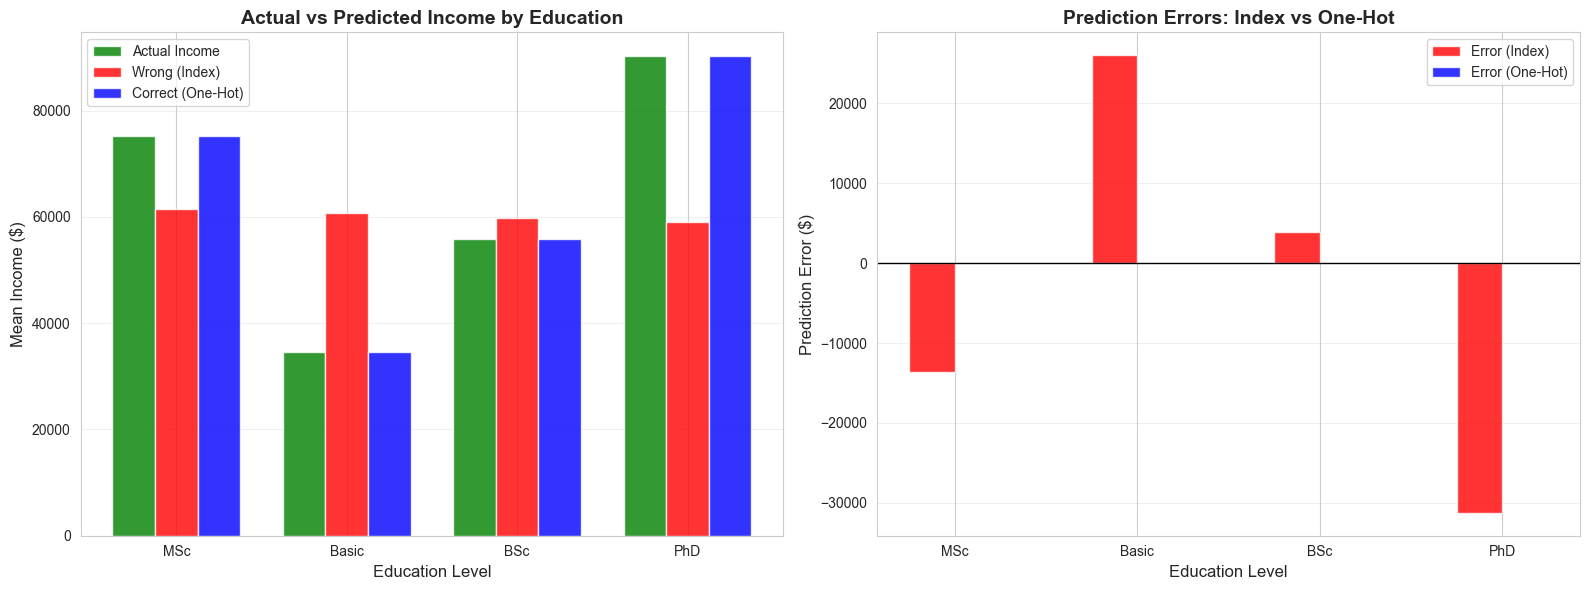

In [12]:
# Final visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Group data for plotting
plot_data = df.groupby('Education').agg({
    'Income': 'mean',
    'Predicted_Income_Wrong': 'mean',
    'Predicted_Correct': 'mean',
    'EducationIndex': 'first'
}).reset_index().sort_values('EducationIndex')

x = np.arange(len(plot_data))
width = 0.25

# Left plot: Bar comparison
axes[0].bar(x - width, plot_data['Income'], width, label='Actual Income', color='green', alpha=0.8)
axes[0].bar(x, plot_data['Predicted_Income_Wrong'], width, label='Wrong (Index)', color='red', alpha=0.8)
axes[0].bar(x + width, plot_data['Predicted_Correct'], width, label='Correct (One-Hot)', color='blue', alpha=0.8)
axes[0].set_xlabel('Education Level', fontsize=12)
axes[0].set_ylabel('Mean Income ($)', fontsize=12)
axes[0].set_title('Actual vs Predicted Income by Education', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_data['Education'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Right plot: Residuals (errors)
residuals_wrong = plot_data['Predicted_Income_Wrong'] - plot_data['Income']
residuals_correct = plot_data['Predicted_Correct'] - plot_data['Income']

axes[1].bar(x - width/2, residuals_wrong, width, label='Error (Index)', color='red', alpha=0.8)
axes[1].bar(x + width/2, residuals_correct, width, label='Error (One-Hot)', color='blue', alpha=0.8)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Education Level', fontsize=12)
axes[1].set_ylabel('Prediction Error ($)', fontsize=12)
axes[1].set_title('Prediction Errors: Index vs One-Hot', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_data['Education'])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Part 5: Using Statistical Models for More Insight

Let's use statsmodels to see the statistical significance of our approach.

In [13]:
# Prepare data for statsmodels
df_stats = df[['Education', 'Income']].copy()
df_stats['Education'] = pd.Categorical(df_stats['Education'])

# Fit model with one-hot encoding (statsmodels does this automatically)
model_stats = ols('Income ~ C(Education)', data=df_stats).fit()

print("\n" + "="*60)
print("STATISTICAL MODEL: Using Education as Categorical Variable")
print("="*60)
print(model_stats.summary())

print("\n" + "="*60)
print("KEY INSIGHTS FROM STATISTICAL MODEL")
print("="*60)
print(f"\nR-squared: {model_stats.rsquared:.4f}")
print(f"  → The model explains {model_stats.rsquared*100:.2f}% of income variation")
print(f"\nF-statistic p-value: {model_stats.f_pvalue:.2e}")
print(f"  → Education is {'highly' if model_stats.f_pvalue < 0.001 else ''} significant predictor of income")
print(f"\nEach education level has its own effect (not constrained to linear relationship)!")


STATISTICAL MODEL: Using Education as Categorical Variable
                            OLS Regression Results                            
Dep. Variable:                 Income   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     2064.
Date:                Wed, 05 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:25:10   Log-Likelihood:                -10383.
No. Observations:                1000   AIC:                         2.077e+04
Df Residuals:                     996   BIC:                         2.079e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

## Summary: Why One-Hot Encoding is Essential

### ❌ **Problem with Using Index as Numerical Feature:**

1. **Assumes Ordering**: The model thinks index 0 < 1 < 2 < 3 has meaning
2. **Assumes Equal Intervals**: Moving from 0→1 is treated the same as 2→3
3. **Assumes Linear Relationship**: Each unit increase in index has same effect
4. **Loses Information**: Can't capture the true, independent effect of each category

### ✅ **Benefits of One-Hot Encoding:**

1. **No Ordering Assumption**: Each category is independent
2. **Individual Effects**: Each education level can have its own unique effect on income
3. **Captures True Relationships**: Can model non-linear, unordered relationships
4. **Better Predictions**: More accurate because it respects the categorical nature

### 🎯 **The Key Insight:**

**It's not about avoiding fractional predictions.** It's about **not imposing false mathematical relationships** on categorical data.

When you use an index as a numerical feature, you're telling the model:
- "These categories have a natural order"
- "The distance between categories is equal"
- "The relationship is linear"

But for most categorical variables (education, marital status, country, etc.), **none of these assumptions are true!**

One-hot encoding lets each category speak for itself, without imposing false mathematical structure.

## Connection to PySpark StringIndexer + OneHotEncoder

In your original PySpark code:

```python
# This creates indices (0, 1, 2, ...) based on frequency
indexer_edu = StringIndexer(inputCol='Education', outputCol='EducationIndex')

# This converts indices to one-hot vectors: [1,0,0], [0,1,0], [0,0,1]
encoder = OneHotEncoder(inputCols=['EducationIndex'], outputCols=['EducationVec'])
```

The **indexing step** is just an intermediate step - it's **NOT** meant to be used directly as a feature!

The **one-hot encoding step** converts those indices into proper categorical features that can be used in machine learning models.

**In PySpark, the final EducationVec is a sparse vector like:**
- MSc (index 0): `[1.0, 0.0, 0.0]`
- Basic (index 1): `[0.0, 1.0, 0.0]`
- BSc (index 2): `[0.0, 0.0, 1.0]`
- PhD (index 3): `[0.0, 0.0, 0.0]` (reference category)

This is equivalent to the pandas `get_dummies()` we used in this notebook!

## But Wait... What if We Order the Categories "Correctly"?

### A Common Follow-Up Question:

> "The problem is just the ordering! Why don't we assign labels based on the real-world order? Like: Basic=0, BSc=1, MSc=2, PhD=3?"

### The Answer: What IS the "Real-World Order"?

This approach works **only if**:
1. There is an **objective, universal ordering** for the categories
2. The **intervals between categories are meaningful and roughly equal**
3. The relationship with the target variable is **actually linear**

#### ✅ Examples where ordering *might* work:
- **T-shirt sizes**: Small (0) < Medium (1) < Large (2) < XL (3)
  - Clear ordering, roughly equal intervals
- **Education levels** (in some contexts): High School < Bachelor's < Master's < PhD
  - Generally increasing, but intervals not equal (2 years vs 4 years vs 5+ years)

#### ❌ Examples where ordering *doesn't work*:

**Marital Status**: Single, Married, Divorced, Widowed
- What's the "order"? 
- Is Divorced "higher" or "lower" than Married?
- Is Widowed "more" than Divorced?
- **There is no meaningful numerical ordering!**

**Country/Region**: USA, UK, India, China, Brazil
- No natural order at all
- Even alphabetical order has no relationship to any outcome

**Color**: Red, Blue, Green, Yellow
- No inherent ordering
- Even if you order by wavelength, it doesn't mean Red is "less than" Blue

**Product Category**: Electronics, Clothing, Food, Books
- Completely nominal - no ordering relationship

**Day of Week**: Monday, Tuesday, ..., Sunday
- Cyclical, not linear! Sunday isn't "greater than" Monday
- The "distance" from Saturday to Sunday is the same as Sunday to Monday (1 day)

### The Fundamental Issue: Ordinality vs. Cardinality

Even when there *is* a meaningful order (like education), using numerical encoding assumes:

1. **Equal intervals**: The difference between Basic→BSc is the same as MSc→PhD
   - In reality: Basic→BSc might be 3 years, while MSc→PhD could be 5+ years
   
2. **Linear relationship**: Each step up has the same effect on the outcome
   - In reality: Going from BSc→MSc might increase income by $20k, while MSc→PhD might only add $15k (or vice versa!)

3. **Additive effects**: If BSc is 1 and MSc is 2, the model thinks "two BSc's = one MSc"
   - Obviously nonsensical!

### The Safe Approach: One-Hot Encoding

**Unless you have strong domain knowledge AND evidence that:**
- The ordering is universal and meaningful
- The intervals are roughly equal
- The relationship is truly linear

**→ Use one-hot encoding!**

It's safer to let each category have its own independent effect, rather than imposing a structure that might not exist.

### Summary:
The question "why not order them correctly?" assumes there *is* a correct order. For many categorical variables (marital status, country, color, product type, etc.), **there is no meaningful order at all**. And even when there is (like education), the ordering might not reflect equal intervals or linear relationships with your target variable.

**One-hot encoding is the default choice because it makes no assumptions about the categorical variable's structure.**